# Gemma 2 9B 파인튜닝 노트북
**대상 GPU**: Google Colab T4 (16GB VRAM)  
**기법**: QLoRA (4-bit) + SFT via Unsloth

## 실행 전 체크리스트
1. 런타임 → 런타임 유형 변경 → **T4 GPU** 선택
2. Google Drive에 프로젝트 폴더 업로드 (`gymbarofit/gemma2/`)
3. 셀을 순서대로 실행

## 셀 1: GPU 확인

In [3]:
import torch

if not torch.cuda.is_available():
    raise RuntimeError("GPU가 연결되지 않았습니다. 런타임 유형을 T4 GPU로 변경하세요.")

gpu_name = torch.cuda.get_device_name(0)
vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"GPU : {gpu_name}")
print(f"VRAM: {vram_gb:.1f} GB")

if "T4" not in gpu_name:
    print("[WARNING] T4가 아닙니다. 메모리 설정을 재확인하세요.")

GPU : Tesla T4
VRAM: 15.6 GB


## 셀 2: 패키지 설치

In [ ]:
%pip install -q \
    "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git" \
    "trl>=0.11.0" \
    "peft>=0.13.0" \
    "transformers>=4.45.0" \
    "datasets>=3.0.0" \
    "bitsandbytes>=0.44.0" \
    "pyyaml>=6.0" \
    "wandb>=0.18.0" \
    "python-dotenv>=1.0.0"

print("설치 완료")

## 셀 3: W&B 로그인

In [ ]:
import os
import wandb
from dotenv import load_dotenv

# .env 파일을 /content/ 에 업로드한 뒤 실행하세요
# 파일 내용 예시:  WANDB_API_KEY=your_key_here
load_dotenv("/content/.env")

WANDB_API_KEY = os.environ.get("WANDB_API_KEY", "")
if not WANDB_API_KEY:
    raise ValueError(".env 파일에 WANDB_API_KEY가 설정되어 있지 않습니다.")

wandb.login(key=WANDB_API_KEY)
wandb.init(entity="finemini2001-sungkyunkwan-university", project="gymbarofit")

## 셀 4: 프로젝트 경로 확인

> 아래 파일들을 Colab 파일 탭에서 `/content/` 에 직접 업로드하세요:
> - `train.py`
> - `config/lora_config.yaml`
> - `data/train.jsonl`
> - `data/val.jsonl`
> - `data/dataset_config.json`

In [7]:
import os

os.chdir("/content")

required = [
    "data/train.jsonl",
    "data/val.jsonl",
    "data/dataset_config.json",
    "train.py",
    "config/lora_config.yaml",
]
for path in required:
    status = "OK" if os.path.exists(path) else "MISSING"
    print(f"  [{status}] {path}")

  [OK] data/train.jsonl
  [OK] data/val.jsonl
  [OK] data/dataset_config.json
  [OK] train.py
  [OK] config/lora_config.yaml


## 셀 5: 데이터 샘플 확인

In [8]:
import json

with open("data/dataset_config.json", encoding="utf-8") as f:
    config = json.load(f)
print("[Instruction]")
print(config["instruction"])
print()

with open("data/train.jsonl", encoding="utf-8") as f:
    sample = json.loads(f.readline())

print("[Sample Input]")
print(sample["input"])
print()
print("[Sample Output]")
print(sample["output"])

[Instruction]
당신은 전문 퍼스널 트레이너입니다. 아래 회원의 운동 기록을 분석하고, 전문적인 피드백과 다음 운동 추천을 제공하세요.

[Sample Input]
나이: 20세 | 성별: 남성 | 체중: 111.0kg | 키: 1.94m | BMI: 29.49(비만 1단계)
체지방률: 27.6% | 안정시 심박수: 50.0bpm
운동 유형: 유산소 | 경험 수준: 중급 | 주 4회 운동
이번 세션: 1.02시간 | 평균 심박수: 156.0bpm | 최대 심박수: 170.0bpm
소모 칼로리: 875.0kcal | 수분 섭취: 3.3L

[Sample Output]
## 운동 기록 분석

**신체 지표**: BMI 29.49로 비만 1단계 범주에 해당합니다. 체지방률(27.6%)이 높습니다. 유산소 운동 비중을 늘리는 것이 좋습니다.

**이번 세션 강도**: 평균 심박수 156.0bpm은 최대 심박수 대비 '최대 운동' 구간으로, 1.02시간 동안 총 875.0kcal를 소모했습니다. (시간당 857.8kcal)

**수분 관리**: 수분 섭취(3.3L)가 충분합니다.

## 다음 운동 추천

인터벌 달리기(1분 전력·2분 회복 × 6세트)를 추가해 심폐 능력을 향상시키세요. 체지방 감량을 위해 HIIT를 주 1~2회 병행하는 것을 추천합니다. 이번 세션 심박수 구간이 '최대 운동'으로 매우 높았습니다. 다음 세션은 강도를 10~15% 낮춰 과훈련을 예방하세요.


## 셀 6: 학습 실행

778건 × 3 epoch 기준 T4에서 약 **30~50분** 소요됩니다.

In [9]:
!python train.py

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
[1/5] 모델 로드: unsloth/gemma-2-9b-it-bnb-4bit
==((====))==  Unsloth 2026.4.4: Fast Gemma2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
model.safetensors: 100% 6.13G/6.13G [02:34<00:00, 39.6MB/s]
Loading weights: 100% 464/464 [00:22<00:00, 20.31it/s]
generation_config.json: 100% 190/190 [00:00<00:00, 1.09MB/s]
config.json: 1.41kB [00:00, 4.62MB/s]
tokenizer_config.json: 47.0kB [00:00, 89.4MB/s]
tokenizer.json: 100% 17.5M/17.5M [00:00<00:00, 21.6MB/s]
special_tokens_map.json: 100% 636/636 [00:00<00:00

## 셀 7: Loss 시각화

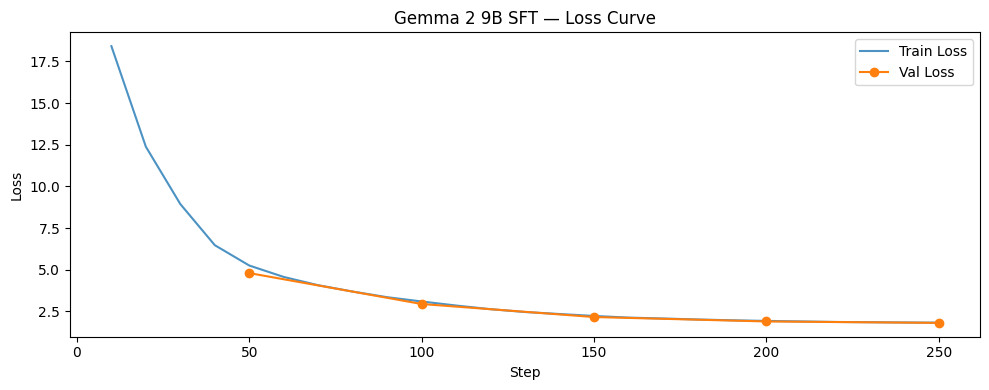

최종 train loss: 1.8249
최종 val   loss: 1.8118


In [10]:
import json
import matplotlib.pyplot as plt
from pathlib import Path

# trainer_state.json 에서 로그 읽기
state_path = Path("models/gemma2-fitness-lora/trainer_state.json")
if not state_path.exists():
    # 체크포인트 디렉터리에서 탐색
    for p in Path("models/gemma2-fitness-lora").glob("checkpoint-*/trainer_state.json"):
        state_path = p
        break

with open(state_path, encoding="utf-8") as f:
    state = json.load(f)

logs = state["log_history"]
train_steps  = [l["step"] for l in logs if "loss" in l]
train_losses = [l["loss"] for l in logs if "loss" in l]
eval_steps   = [l["step"] for l in logs if "eval_loss" in l]
eval_losses  = [l["eval_loss"] for l in logs if "eval_loss" in l]

plt.figure(figsize=(10, 4))
plt.plot(train_steps, train_losses, label="Train Loss", alpha=0.8)
plt.plot(eval_steps, eval_losses, label="Val Loss", marker="o")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Gemma 2 9B SFT — Loss Curve")
plt.legend()
plt.tight_layout()
plt.savefig("models/loss_curve.png", dpi=150)
plt.show()
print(f"최종 train loss: {train_losses[-1]:.4f}")
print(f"최종 val   loss: {eval_losses[-1]:.4f}")

## 셀 8: 추론 테스트

In [14]:
from unsloth import FastLanguageModel
import torch, json

ADAPTER_PATH = "models/gemma2-fitness-lora"
MAX_SEQ_LENGTH = 2048

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=ADAPTER_PATH,
    max_seq_length=MAX_SEQ_LENGTH,
    load_in_4bit=True,
)
FastLanguageModel.for_inference(model)

# 테스트 입력
with open("data/dataset_config.json", encoding="utf-8") as f:
    instruction = json.load(f)["instruction"]

test_input = (
    "나이: 28세 | 성별: 여성 | 체중: 58.0kg | 키: 1.65m | BMI: 21.3(정상)\n"
    "체지방률: 24.0% | 안정시 심박수: 62bpm\n"
    "운동 유형: 근력 | 경험 수준: 초급 | 주 3회 운동\n"
    "이번 세션: 1.0시간 | 평균 심박수: 135bpm | 최대 심박수: 175bpm\n"
    "소모 칼로리: 420kcal | 수분 섭취: 1.5L"
)

prompt = (
    f"<start_of_turn>user\n{instruction}\n\n{test_input}<end_of_turn>\n"
    f"<start_of_turn>model\n"
)

inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=512,
        temperature=0.0,
        do_sample=False,
        repetition_penalty=1.2,
    )


response = tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
print("Response: ")
print(response)

==((====))==  Unsloth 2026.4.4: Fast Gemma2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/464 [00:00<?, ?it/s]

Unsloth: Will load unsloth/gemma-2-9b-it-bnb-4bit as a legacy tokenizer.
Both `max_new_tokens` (=512) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Response: 
# ## #################################################################################################################################////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////// //// /////////<//<//[//(//"//'//.//_//$ //$ ////﻿//﻿/* autorytatywna<unused99><2mass>[@BOS@] Mask maskmaskMask masks masquemasque masques maske Maske máscara mascarilla capucha aisladoambién<unused0><unused1><unused2><unused18><unused3><unused4><unused5><unused6><unused7><unused8><unused9><unused10><unused11><unused12><unused13><unused14><unused15><unused16><unused17><unused19><unused20><unused21><unused22><unused23><unused24><unused25><unused26><unused27><unused28><unused29><unused30><unused31><unused32><unused33><unused34><unused35><unused36><unused37><unused38><unused39><unused40><unused41><unused42><unused43><unused44><unused45><unused46><unused47><unused48><unused49><unused50><unused51><unused52><unused53><un

## 셀 9: 어댑터 Drive 백업

In [15]:
import shutil, os
from google.colab import drive

drive.mount("/content/drive")

BACKUP_DIR = "/content/drive/MyDrive/gymbarofit/gemma2/models/gemma2-fitness-lora"
os.makedirs(BACKUP_DIR, exist_ok=True)

src = "/content/models/gemma2-fitness-lora"
for fname in os.listdir(src):
    if fname.endswith(("safetensors", ".json", ".model")):
        shutil.copy(os.path.join(src, fname), BACKUP_DIR)
        print(f"  복사: {fname}")

print("Drive 백업 완료")

Mounted at /content/drive
  복사: adapter_model.safetensors
  복사: tokenizer.json
  복사: adapter_config.json
  복사: tokenizer_config.json
Drive 백업 완료
